# Clustering

Data-Mining-Techniken können in zwei Typen unterteilt werden können: deskriptive und prädiktive (siehe Abbildung unten).

<center>

![Data Mining Techniken](https://www.researchgate.net/profile/Ali_Al-Haboobi/publication/317731072/figure/fig1/AS:507840017645568@1498089903893/Data-mining-techniques_W640.jpg)

</center>

Clustering ist also eine unüberwachte, deskriptive Aufgabe. Eine unüberwachte Lernmethode versucht, Muster aus einem Datensatz zu erkennen, der aus Beispielen ohne beschriftete Antworten besteht. Beim Clustering besteht das Ziel darin, die natürlich vorkommenden Gruppen ähnlicher Beispiele im Datensatz zu identifizieren.

<center>

![alt text](https://media.geeksforgeeks.org/wp-content/uploads/merge3cluster.jpg)

</center>

Eine beliebte Anwendung des Clustering ist die Marktsegmentierung. Aus Wikipedia:

> Marktsegmentierung ist die Aktivität, einen breiten Verbraucher- oder Unternehmensmarkt, der normalerweise aus bestehenden und potenziellen Kunden besteht, in Untergruppen von Verbrauchern (sogenannte Segmente) aufzuteilen, die auf einer Art gemeinsamer Merkmale basieren.

![alt text](https://dotcom.nlcdn.com/wp-content/uploads/2019/10/Market-Segmentation_Featured-1140x768@2x-80-min.jpg)

Es gibt mehrere Algorithmen für Clustering. Hier werden wir zwei davon untersuchen: $k$-Means und DBSCAN.





## Der $k$-Means Algorithmus

Der $k$-Means-Algorithmus sucht nach einer vorgegebenen Anzahl von Gruppen (*Clustern*) in einem unbezeichneten, mehrdimensionalen Datensatz. Dies geschieht anhand einer einfachen Vorstellung davon, wie ein idealer Cluster aussehen sollte:

* Das „Clusterzentrum“ ist das arithmetische Mittel aller Punkte, die zu diesem Cluster gehören.
* Jeder Punkt ist seinem eigenen Clusterzentrum näher als anderen Clusterzentren.

Die folgende Abbildung ([Quelle](http://shabal.in/visuals/kmeans/2.html)) veranschaulicht das Verhalten von $k$-Means. 

![K-Means Animation](https://shabal.in/visuals/kmeans/left.gif)

Dieser [Link](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/) bietet einige Visualisierungen für ein intuitives Verständnis des Verhaltens von $k$-Means (Ein Klick auf den Link bietet eine Visualisierung als `*.gif`-Datei).


### $k$-Means in Scikit-Learn

Scikit-Learn bietet eine Implementierung des $k$-Means-Algorithmus.

Zuerst erzeugen wir uns mit der [`make_blobs`-Fuktion](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) einen Datensatz, den wir mit der [`scatter`-Fuktion](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) visualisieren können.

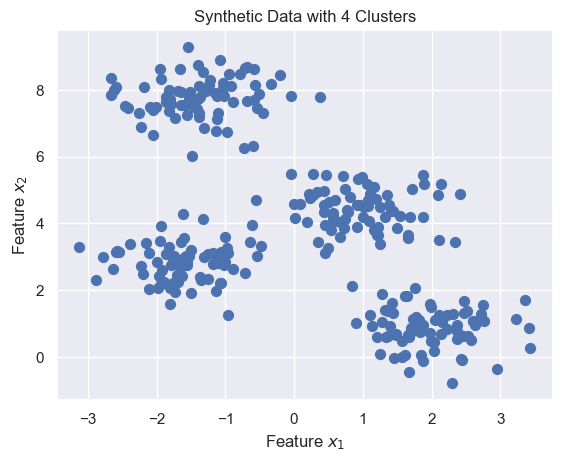

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np

from sklearn.datasets import make_blobs

### BEGIN SOLUTION
# generate synthetic data containing 4 clusters with some noise and random state for reproducibility
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
#visualize the data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Data with 4 Clusters")
plt.xlabel("Feature $x_1$")
plt.ylabel("Feature $x_2$");
### END SOLUTION

Der obige Datensatz weist eindeutig eine Clusterstruktur mit vier Clustern auf. Daher konfigurieren wir $k$-Means mit `n_clusters=4`.


In [35]:
from sklearn.cluster import KMeans

# notice that we have to provide the amount of clusters we want.
kmeans = KMeans(n_clusters=4)

# run k-means to find the clustering configuration
kmeans.fit(X)

# each cluster is identified by an integer label
y_kmeans = kmeans.predict(X)

In [36]:
print(y_kmeans.shape)

(300,)


Die Funktion `predict` gibt die Cluster-Labels zurück, denen jeder Punkt zugewiesen wurde.


In [37]:
y_kmeans

array([0, 1, 2, 3, 0, 0, 2, 2, 3, 3, 2, 1, 2, 1, 0, 2, 2, 0, 2, 2, 0, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 3, 1, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2, 2, 2,
       2, 2, 3, 2, 1, 0, 2, 0, 3, 0, 0, 2, 3, 2, 1, 0, 1, 2, 3, 2, 2, 2,
       1, 0, 1, 2, 2, 2, 3, 2, 2, 3, 2, 2, 0, 3, 0, 2, 0, 0, 3, 2, 0, 2,
       1, 1, 2, 0, 3, 2, 2, 2, 0, 0, 2, 2, 3, 0, 3, 0, 2, 0, 0, 2, 1, 2,
       2, 2, 0, 1, 0, 2, 1, 0, 0, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 3, 2,
       2, 0, 1, 2, 2, 1, 2, 3, 1, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2,
       0, 2, 3, 2, 0, 2, 1, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 3, 0, 2, 2, 3,
       0, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 0, 2, 2, 1, 2, 3, 2, 1, 2, 2, 2, 2, 1, 2, 2, 0, 0, 2,
       1, 0, 0, 2, 0, 2, 2, 3, 3, 2, 2, 3, 2, 0, 2, 2, 0, 2, 3, 2, 0, 2,
       0, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 2, 2, 2, 2, 0, 0, 1, 2, 2, 2, 0,
       3, 2, 2, 3, 2, 0, 0, 2, 2, 0, 0, 0, 0, 2, 3, 1, 0, 0, 2, 0, 0, 0,
       1, 2, 3, 2, 0, 0, 1, 3, 3, 0, 0, 2, 3, 2], d

Dieselbe Information kann über das Attribut `labels_` abgerufen werden.


In [38]:
print(kmeans.labels_)

[0 1 2 3 0 0 2 2 3 3 2 1 2 1 0 2 2 0 2 2 0 0 2 2 2 2 0 2 2 2 3 1 2 1 1 1 1
 1 2 0 2 2 2 2 2 2 3 2 1 0 2 0 3 0 0 2 3 2 1 0 1 2 3 2 2 2 1 0 1 2 2 2 3 2
 2 3 2 2 0 3 0 2 0 0 3 2 0 2 1 1 2 0 3 2 2 2 0 0 2 2 3 0 3 0 2 0 0 2 1 2 2
 2 0 1 0 2 1 0 0 2 2 0 2 0 0 0 0 2 0 2 3 2 2 0 1 2 2 1 2 3 1 2 2 2 2 2 1 2
 1 1 1 2 1 2 0 2 3 2 0 2 1 2 2 0 2 2 2 2 0 2 2 3 0 2 2 3 0 0 2 2 0 2 2 2 2
 2 2 2 0 1 2 2 2 2 2 2 2 2 2 1 2 2 0 2 2 1 2 3 2 1 2 2 2 2 1 2 2 0 0 2 1 0
 0 2 0 2 2 3 3 2 2 3 2 0 2 2 0 2 3 2 0 2 0 1 1 1 1 2 2 1 2 2 0 2 2 2 2 0 0
 1 2 2 2 0 3 2 2 3 2 0 0 2 2 0 0 0 0 2 3 1 0 0 2 0 0 0 1 2 3 2 0 0 1 3 3 0
 0 2 3 2]


Wir können auch die Zentren jedes erzeugten Clusters untersuchen:


In [39]:
kmeans.cluster_centers_

array([[ 1.98726097,  0.90144281],
       [-1.73102222,  7.43349916],
       [-0.33514647,  3.62624134],
       [-0.89247947,  8.18394342]])

Für diesen einfachen zweidimensionalen Datensatz können wir die durch $k$-Means erzeugte Clusterkonfiguration visualisieren.

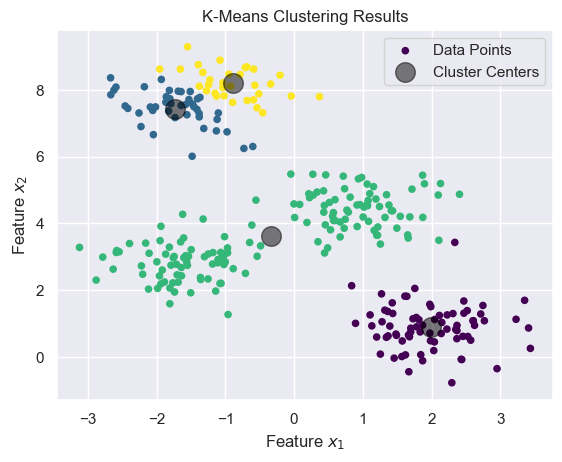

In [40]:
# visualize the clustering results, cmap 'viridis' provides different colors for different clusters
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=20, cmap='viridis')

# plot the cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title("K-Means Clustering Results")
plt.xlabel("Feature $x_1$")
plt.ylabel("Feature $x_2$")
plt.legend(['Data Points', 'Cluster Centers']);

### Diskussion

* Der geeignete Wert $k$ für einen bestimmten Datensatz muss experimentell ermittelt werden. (Mehr dazu später.)

* Es kann notwendig sein, $k$-Means mehrmals auszuführen, um zu einer sinnvollen Clusterkonfiguration zu gelangen.

* $k$-Means funktioniert gut, wenn die natürlich vorkommenden Cluster im Datensatz:

  * ungefähr kugelförmig sind,
  * gut voneinander getrennt sind,
  * ähnliche Volumina haben,
  * eine ähnliche Anzahl von Punkten enthalten.

Beispiel für ungefähr kugelförmige Cluster (links und rechts):

![alt text](https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs40595-016-0086-9/MediaObjects/40595_2016_86_Fig1_HTML.gif?as=webp)

Beispiel für nicht kugelförmige Cluster:

<img src="https://media.geeksforgeeks.org/wp-content/uploads/clusteringg.jpg" width="400"/>

Beispiel für gut getrennte (links) und nicht gut getrennte (rechts) Cluster:

![alt text](https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs40595-016-0086-9/MediaObjects/40595_2016_86_Fig2_HTML.gif?as=webp)


Das folgende Beispiel zeigt ein Szenario, in dem $k$-Means nicht der geeignete Clustering-Algorithmus ist (da die Cluster nicht annähernd kugelförmig sind).


In [41]:
from sklearn.datasets import make_moons

# create synthetic data in the shape of two interleaving half circles
X, y = make_moons(200, noise=.05, random_state=0)

print(X.shape, "Data points created (2 features each).")

(200, 2) Data points created (2 features each).


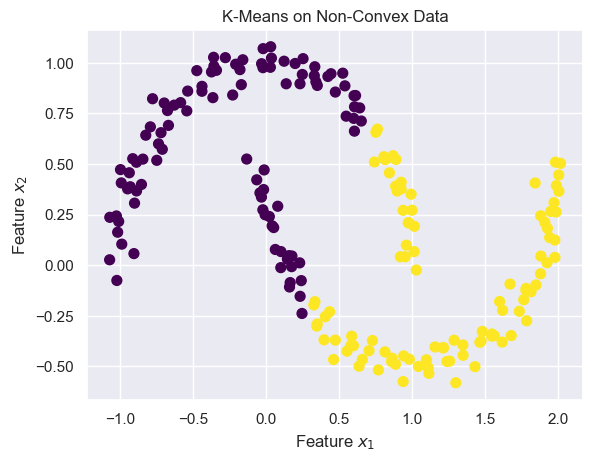

In [42]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis')
plt.title("K-Means on Non-Convex Data");
plt.xlabel("Feature $x_1$")
plt.ylabel("Feature $x_2$");

## DBSCAN: Density-based spatial clustering of applications with noise

Der DBSCAN-Algorithmus (*Density-Based Spatial Clustering of Applications with Noise*) basiert auf der Vorstellung, dass ein Cluster eine dichte Ansammlung räumlich nahe beieinanderliegender Punkte ist. Die Grundidee ist: Wenn ein bestimmter Punkt zu einem Cluster gehört, muss er in der Nähe vieler anderer Punkte desselben Clusters liegen.

DBSCAN hat zwei Hyperparameter:

* $\epsilon \in \Re$
* minPoints $\in \mathbb{Z}$

Basierend auf den Werten dieser Hyperparameter kategorisiert DBSCAN jeden Punkt im Datensatz als einen von drei möglichen Typen: **Kernpunkt**, **Randpunkt** oder **Ausreißer**. Betrachten wir einen Punkt $p$ im Datensatz:

* $p$ wird als *Kernpunkt* bezeichnet, wenn sich mindestens `minPoints` Punkte innerhalb seiner Kugel befinden (einschließlich $p$ selbst).

* Wenn $p$ kein Kernpunkt ist, aber höchstens in einem Abstand von $\epsilon$ zu einem Kernpunkt liegt, dann wird $p$ als *Randpunkt* (auch *Kantenpunkt* genannt) bezeichnet.

* Wenn $p$ weder ein Kernpunkt noch ein Kantenpunkt ist, wird $p$ als *Ausreißer* (auch *Rauschpunkt* genannt) bezeichnet.

Das folgende Bild ([Quelle](https://www.kdnuggets.com/2020/04/dbscan-clustering-algorithm-machine-learning.html)) zeigt die drei Punkttypen.

![texto alternativo](https://miro.medium.com/max/627/1*yT96veo7Zb5QeswV7Vr7YQ.png)

Um zu verstehen, wie DBSCAN diese Punktkategorien verwendet, um Cluster in Daten zu finden, betrachten wir das folgende Bild ([Quelle](https://en.wikipedia.org/wiki/DBSCAN)), das neun Punkte in einem zweidimensionalen Beispieldatensatz zeigt. Diese Punkte sind blau, rot oder gelb gefärbt. Jeder Punkt hat eine Kugel um sich herum mit dem Radius $\epsilon$. Außerdem gilt $\operatorname{minPoints} = 4$.
Die roten Punkte sind Kernpunkte, da ihre jeweiligen Kugeln mindestens 4 Punkte enthalten.
Die gelben Punkte sind keine Kernpunkte, liegen aber in der Reichweite eines Kernpunkts; daher sind sie Kantenpunkte.
Der blaue Punkt ist ein Ausreißer.

![alt text](https://upload.wikimedia.org/wikipedia/commons/thumb/a/af/DBSCAN-Illustration.svg/1024px-DBSCAN-Illustration.svg.png)

Zu Beginn seiner Ausführung wählt DBSCAN zufällig einen Punkt $p$ aus dem Datensatz. Wenn sich mindestens $\operatorname{minPoints}$ Punkte in einem Abstand von höchstens $\epsilon$ um $p$ befinden (einschließlich $p$ selbst), betrachtet DBSCAN alle diese Punkte als Teil eines „Clusters“.
Dann wird dieser Cluster erweitert, indem alle Punkte innerhalb der $\epsilon$-Kugel von $p$ überprüft werden; wenn sie entweder Kern- oder Randpunkte sind, werden sie rekursiv dem Cluster hinzugefügt. Schließlich gibt es keine weiteren Punkte mehr, die hinzugefügt werden können.
An diesem Punkt wählt DBSCAN einen neuen beliebigen Punkt aus und wiederholt den Prozess.
Es kann vorkommen, dass der ausgewählte Punkt $p$ weniger als $\operatorname{minPoints}$ Punkte in seiner $\epsilon$-Kugel hat und auch zu keinem anderen Cluster gehört. In diesem Fall wird $p$ als „Rauschpunkt“ betrachtet und keinem Cluster zugewiesen.

Das folgende Bild ([Quelle](https://julienbeaulieu.gitbook.io/wiki/sciences/machine-learning/unsupervised-learning/cluster-validation)) zeigt ein Beispiel für eine mögliche Clusterkonfiguration, die DBSCAN finden kann.

![alt text](https://gblobscdn.gitbook.com/assets%2F-LagOeJ2nL90MQERwhxy%2F-LmpDXaJYiI3aUWErGxL%2F-LmucpOLDDwbrC_bUPRG%2Fimage.png?alt=media\&token=6cee1e81-220c-4a8a-a8c0-e68dbd2b749d)

Der folgende Link veranschaulicht das Verhalten von DBSCAN während der Ausführung visuell:
[https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)


### DBSCAN in Scikit-Learn

Scikit-Learn stellt eine Implementierung von DBSCAN über die Klasse [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) bereit. In dieser Klasse entsprechen die Parameter `eps` und `min_samples` den Werten $\epsilon$ bzw. $\operatorname{minPoints}$.

Nachdem die Funktion `fit` aufgerufen wurde, können die von DBSCAN gefundenen Cluster über das Attribut `labels_` eingesehen werden.

Das folgende Beispiel, angepasst aus der [Scikit-Learn-Dokumentation](https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html), zeigt, wie die Klasse [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) verwendet werden kann.


Zuerst wird ein synthetischer Datensatz erzeugt. Beachte, dass sich die Punkte in diesem Datensatz natürlich in drei Cluster gruppieren.


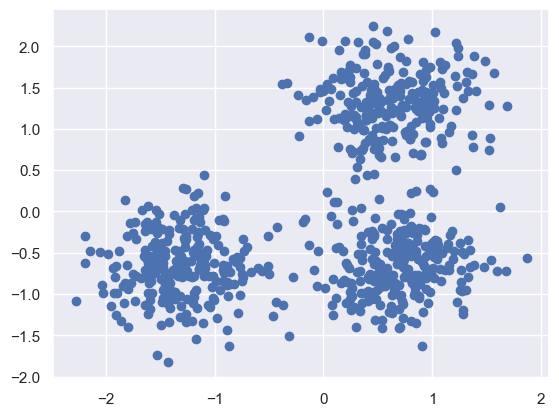

In [43]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# #############################################################################
# Generate sample data
centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(n_samples=750, centers=centers, cluster_std=0.4,
                            random_state=0)

# Before running any clustering algorithm that uses distances
# as a part of its optimization, it is important to scale features.
X = StandardScaler().fit_transform(X)

plt.plot(X[:, 0], X[:, 1], 'o', markersize=6)

Nun wird DBSCAN angewendet.


In [44]:
import numpy as np

from sklearn.cluster import DBSCAN

# #############################################################################
# Compute DBSCAN
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

In [45]:
print(labels)

[ 0  1  0  2  0  1  1  2  0  0  1  1  1  2  1  0 -1  1  1  2  2  2  2  2
  1  1  2  0  0  2  0  1  1  0  1  0  2  0  0  2  2  1  1  1  1  1  0  2
  0  1  2  2  1  1  2  2  1  0  2  1  2  2  2  2  2  0  2  2  0  0  0  2
  0  0  2  1 -1  1  0  2  1  1  0  0  0  0  1  2  1  2  2  0  1  0  1 -1
  1  1  0  0  2  1  2  0  2  2  2  2 -1  0 -1  1  1  1  1  0  0  1  0  1
  2  1  0  0  1  2  1  0  0  2  0  2  2  2  0 -1  2  2  0  1  0  2  0  0
  2  2 -1  2  1 -1  2  1  1  2  2  2  0  1  0  1  0  1  0  2  2 -1  1  2
  2  1  0  1  2  2  2  1  1  2  2  0  1  2  0  0  2  0  0  1  0  1  0  1
  1  2  2  0  0  1  1  2  1  2  2  2  2  0  2  0  2  2  0  2  2  2  0  0
  1  1  1  2  2  2  2  1  2  2  0  0  2  0  0  0  1  0  1  1  1  2  1  1
  0  1  2  2  1  2  2  1  0  0  1  1  1  0  1  0  2  0  2  2  2  2  2  1
  1  0  0  1  1  0  0  2  1 -1  2  1  1  2  1  2  0  2  2  0  1  2  2  0
  2  2  0  0  2  0  2  0  2  1  0  0  0  1  2  1  2  2  0  2  2  0  0  2
  1  1  1  1  1  0  1  1  1  1  0  0  1  1  1  0  2

Abschließend wird die Clustering-Lösung unten dargestellt. In der erzeugten Clusterung ist zu sehen, dass die von DBSCAN als Ausreißer kategorisierten Punkte in Schwarz dargestellt sind. Die grünen, roten und gelben Punkte befinden sich in einem der drei dichten Cluster, die vom Algorithmus gefunden wurden.


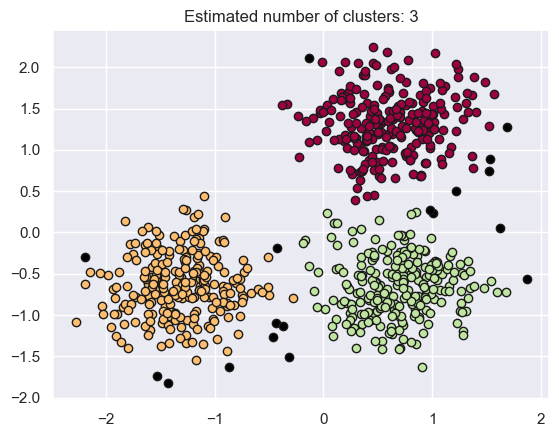

In [46]:
# #############################################################################
# Plot result
import matplotlib.pyplot as plt

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.show()

Das folgende Beispiel zeigt, wie sich DBSCAN im *Two-Moons*-Datensatz verhält.


In [47]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

Nun, da der synthetische Datensatz erzeugt wurde, wenden wir DBSCAN darauf an und visualisieren die erzeugten Cluster.


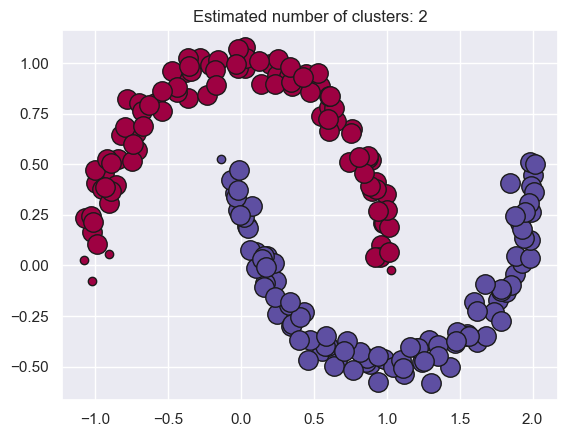

In [48]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# #############################################################################
# Plot result
import matplotlib.pyplot as plt

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.show()

### Diskussion

Auf den ersten Blick scheint DBSCAN die Probleme zu lösen, die bei $k$-Means auftreten. Zum Beispiel muss der Benutzer bei DBSCAN nicht die Anzahl der zu findenden Cluster angeben. Außerdem kann DBSCAN Cluster mit allgemeineren Formen erkennen.
Allerdings ist es in der Praxis nicht einfach, die geeigneten Werte für die Hyperparameter $\operatorname{minPoints}$ und $\epsilon$ für einen bestimmten Datensatz zu finden. Insbesondere kann DBSCAN Schwierigkeiten haben, eine sinnvolle Clusterung für Datensätze zu erzeugen, die räumliche Bereiche mit unterschiedlichen Dichten aufweisen (da es schwierig ist, passende Werte für $\operatorname{minPoints}$ und $\epsilon$ zu bestimmen).


## Cluster-Validierung

Die Cluster-Validierung ist das Verfahren zur Bewertung der Qualität (Güte) einer gegebenen Clusterkonfiguration. Es gibt verschiedene Bewertungsmaße, um eine von einem Algorithmus erzeugte Clusterkonfiguration zu validieren. Diese Maße können in zwei Typen unterteilt werden:

* **Interne Evaluation**, bei der interne Informationen des Clustering-Prozesses verwendet werden, um die Qualität einer Clusterstruktur ohne Bezug auf externe Informationen zu beurteilen.
* **Externe Evaluation**, bei der die Ergebnisse einer Clusteranalyse mit einem bekannten Ergebnis verglichen werden, z. B. mit extern bereitgestellten Klassenlabels. Diese Art der Evaluation misst, inwieweit die Clusterlabels den extern bereitgestellten Klassenlabels entsprechen.


### Adjusted Rand Index (ARI)

Der **ARI** ist eine Funktion, die die Ähnlichkeit zwischen der wahren Klassenzuordnung (*ground truth*) und den vom Algorithmus erzeugten Zuordnungen misst, wobei Permutationen ignoriert werden. Die Hauptmerkmale dieser Kennzahl sind die folgenden:

* Der Wertebereich liegt zwischen **[-1, 1]**:
  Negative Werte weisen auf schlechte Clusterkonfigurationen hin;
  eine Konfiguration, die mit der externen Beschriftung übereinstimmt, hat einen positiven ARI;
  **1.0** entspricht einer perfekten Übereinstimmung.
  Zufällige Zuordnungen von Labels ergeben einen ARI-Wert nahe **0.0**, unabhängig von der Anzahl der Cluster oder Beispiele.

* Es werden **keine Annahmen über die Struktur der Cluster** gemacht. Daher kann diese Kennzahl verwendet werden, um verschiedene Clustering-Algorithmen (wie $k$-Means und DBSCAN) miteinander zu vergleichen.

Das folgende Bild ([Quelle](https://julienbeaulieu.gitbook.io/wiki/sciences/machine-learning/unsupervised-learning/cluster-validation)) zeigt verschiedene ARI-Werte und die dazugehörigen Clusterkonfigurationen.

![alt text](https://gblobscdn.gitbook.com/assets%2F-LagOeJ2nL90MQERwhxy%2F-LmpDXaJYiI3aUWErGxL%2F-LmvIVFepQ2ZuTq01IaV%2Fimage.png?alt=media\&token=6b5e6f2b-acec-4d67-87ed-bfe210efdb19)


Scikit-Learn implementiert mehrere Maße zur Validierung von Clustering-Ergebnissen. Die folgende Codezelle zeigt ein Beispiel, wie der ARI (in Scikit-Learn *Adjusted Rand Score* genannt) berechnet wird.

Wenn die wahren Klassenzuordnungen im Parameter `labels_true` bekannt sind und die vom Clustering-Algorithmus erzeugten Zuordnungen in `labels_pred` übergeben werden, liefert die Funktion `adjusted_rand_score` den entsprechenden ARI-Wert.


In [49]:
from sklearn import metrics

# ground truth
labels_true = [0, 0, 0, 1, 1, 1]

# A perfect match between the ground truth and the assigned labels has maximum ARI.
labels_pred = [1, 1, 1, 2, 2, 2]
print(metrics.adjusted_rand_score(labels_true, labels_pred))

# An imperfect match produces a lower ARI value
labels_pred = [1, 1, 0, 0, 3, 3]
print(metrics.adjusted_rand_score(labels_true, labels_pred))

1.0
0.24242424242424243


Ein schlechtes Clustering ergibt einen negativen oder nahe bei null liegenden ARI-Wert.


In [50]:
labels_true = [0, 1, 2, 0, 3, 4, 5, 1]
labels_pred = [1, 1, 0, 0, 2, 2, 2, 2]
print(metrics.adjusted_rand_score(labels_true, labels_pred))

-0.12903225806451613


### Homogenität (extern)

Ein gutes Clustering ist stark **homogen**, wenn alle seine Cluster nur Datenpunkte enthalten, die Mitglieder einer einzigen Klasse sind.

Diese Metrik ist **unabhängig von den absoluten Werten der Labels**: Eine Permutation der Werte der Klassen- oder Clusterlabels ändert den Wert der Kennzahl in keiner Weise.

In Scikit-Learn wird die Homogenitätsmessung durch die Funktion [homogeneity_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.homogeneity_score.html) implementiert.
Diese Funktion liefert einen Wert zwischen **0.0** und **1.0**, wobei letzterer einem Clustering entspricht, das maximal mit der *Ground Truth* übereinstimmt.


Ein Clustering, das mit der *Ground Truth* übereinstimmt, weist maximale Homogenität auf:


In [51]:
from sklearn.metrics.cluster import homogeneity_score
homogeneity_score([0, 0, 1, 1], [1, 1, 0, 0])

1.0

Ein Nachteil dieser Bewertungsmetrik ist, dass ungeeignete Clusterungen, die die Beispiele in mehr Cluster unterteilen, als natürlich vorhanden sind, dennoch perfekt homogen sein können:


In [52]:
print("%.6f" % homogeneity_score([0, 0, 1, 1], [0, 0, 1, 2]))
print("%.6f" % homogeneity_score([0, 0, 1, 1], [0, 1, 2, 3]))

1.000000
1.000000


Cluster, die Beispiele aus verschiedenen Klassen enthalten, weisen keine homogene Beschriftung auf:


In [53]:
print("%.6f" % homogeneity_score([0, 0, 1, 1, 1], [0, 1, 0, 1, 1]))
print("%.6f" % homogeneity_score([0, 0, 1, 1], [0, 0, 0, 0]))

0.020571
0.000000


### Sum of Squared Errors – SSE (intern)

Die **SSE** ist ein Bewertungsmaß, das sich für Clustering-Algorithmen eignet, die mit dem Konzept eines Clusterzentrums arbeiten, wie z. B. $k$-Means. Dieses Maß entspricht der Summe der quadrierten Abstände aller Beispiele zu den Zentren ihrer jeweiligen Cluster.

Bei $k$-Means kann dieses Maß zusammen mit der [Elbow-Methode](https://en.wikipedia.org/wiki/Elbow_method_%28clustering%29) verwendet werden, um den geeigneten Wert von $k$ für einen bestimmten Datensatz zu bestimmen.
Dabei wird die SSE für verschiedene Werte von $k$ geplottet, um visuell die passende Anzahl von Clustern für einen Datensatz auszuwählen.
Siehe das folgende Diagramm ([Quelle](https://datascienceplus.com/k-means-clustering)):

![alt text](https://datascienceplus.com/wp-content/uploads/2019/09/1.png)


Das folgende Beispiel veranschaulicht die Anwendung der Elbow-Methode, um den geeigneten Wert von $k$ für den Iris-Datensatz zu bestimmen.


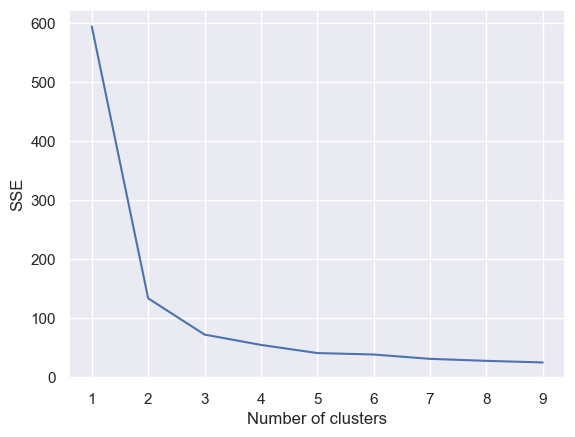

In [54]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris['feature_names'])

data = X[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']]

sse = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(data)
    data["clusters"] = kmeans.labels_
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()

Durch visuelle Inspektion des obigen Diagramms können wir schließen, dass gute Werte für $k$ entweder 2 oder 3 sind.


### Silhouettenanalyse

Aus Wikipedia:

> Der Silhouettenwert ist ein Maß dafür, wie ähnlich ein Objekt seinem eigenen Cluster (Kohäsion) im Vergleich zu anderen Clustern (Trennung) ist. Die Silhouette reicht von −1 bis +1, wobei ein hoher Wert darauf hinweist, dass das Objekt gut zu seinem eigenen Cluster passt und schlecht zu benachbarten Clustern. Wenn die meisten Objekte einen hohen Wert haben, ist die Clusterkonfiguration angemessen. Wenn viele Punkte niedrige oder negative Werte haben, kann die Clusterkonfiguration zu viele oder zu wenige Cluster enthalten.

Dieses Maß variiert im Bereich $[-1, +1]$, wobei gilt:

* Ein Wert nahe **+1** zeigt an, dass das Beispiel weit von benachbarten Clustern entfernt ist – die erzeugten Cluster sind also gut getrennt.
* Ein Wert nahe **0** zeigt an, dass das Beispiel sich innerhalb oder sehr nahe an der Entscheidungsgrenze zwischen zwei benachbarten Clustern befindet – es könnten sich also überlappende Cluster ergeben.
* Ein **negativer Wert** weist darauf hin, dass das Beispiel möglicherweise dem falschen Cluster zugeordnet wurde und dass es einen ähnlicheren Cluster geben könnte.


In Scikit-Learn berechnet die Funktion [silhouette_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) den durchschnittlichen Silhouettenkoeffizienten aller Beispiele in einem Datensatz.

Der Silhouettenkoeffizient für ein Beispiel wird mithilfe des durchschnittlichen **intra-cluster-Abstands** ($a$) und des **durchschnittlichen Abstands zum nächstgelegenen Cluster** ($b$) nach folgender Formel berechnet:

$$
\frac{b - a}{\max(a, b)}
$$

In diesem Ausdruck ist $b$ der Abstand zwischen dem Beispiel und dem nächstgelegenen Cluster, zu dem das Beispiel **nicht** gehört.
Der Silhouettenkoeffizient ist nur definiert, wenn die Anzahl der Cluster $k$ so ist, dass $2 \leq k \leq m - 1$ gilt, wobei $m$ die Anzahl der Beispiele im Datensatz ist.


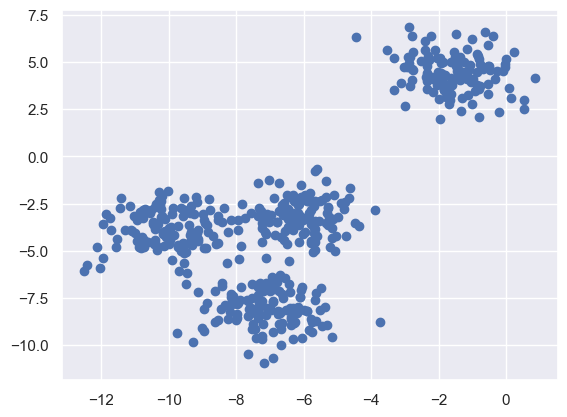

In [55]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import numpy as np

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
X, y = make_blobs(n_samples=500,
                  n_features=2,
                  centers=4,
                  cluster_std=1,
                  center_box=(-10.0, 10.0),
                  shuffle=True,
                  random_state=1)  # For reproducibility

plt.scatter(X[:, 0], X[:, 1])

Ein **Silhouettendiagramm** ist ein Diagramm, das zeigt, wie nah jeder Punkt in einem Cluster an den Punkten in benachbarten Clustern liegt, und bietet somit eine visuelle Möglichkeit, Parameter wie die Anzahl der Cluster zu bewerten.

Im folgenden Codebeispiel ([Quelle](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py)) wird die **Silhouettenanalyse** verwendet, um einen idealen Wert für $k$ (in Scikit-Learn `n_clusters` genannt) auszuwählen.
Das Silhouettendiagramm zeigt, dass `n_clusters`-Werte von **3**, **5** und **6** für den gegebenen Datensatz ungünstig sind – aufgrund der Existenz von Clustern mit Werten unter dem Silhouetten-Durchschnitt sowie großer Schwankungen in der Dicke der Silhouettengrafiken.
Die Silhouettenanalyse ist bei der Entscheidung zwischen den Werten **2** und **4** weniger eindeutig.

Auch an der **Dicke** der Silhouettengrafik lässt sich die **Größe eines Clusters** ablesen.
Das Silhouettendiagramm für Cluster 0, wenn `n_clusters = 2`, ist größer, da es drei Untercluster zu einem großen Cluster zusammenfasst.
Wenn `n_clusters = 4` ist, sind alle Diagramme in etwa gleich dick und damit ähnlich groß – was sich auch im rechts dargestellten, beschrifteten Streudiagramm widerspiegelt.


For n_clusters = 2 The average silhouette_score is : 0.7049787496083262
For n_clusters = 3 The average silhouette_score is : 0.5882004012129721
For n_clusters = 4 The average silhouette_score is : 0.6505186632729437
For n_clusters = 5 The average silhouette_score is : 0.561464362648773
For n_clusters = 6 The average silhouette_score is : 0.4857596147013469


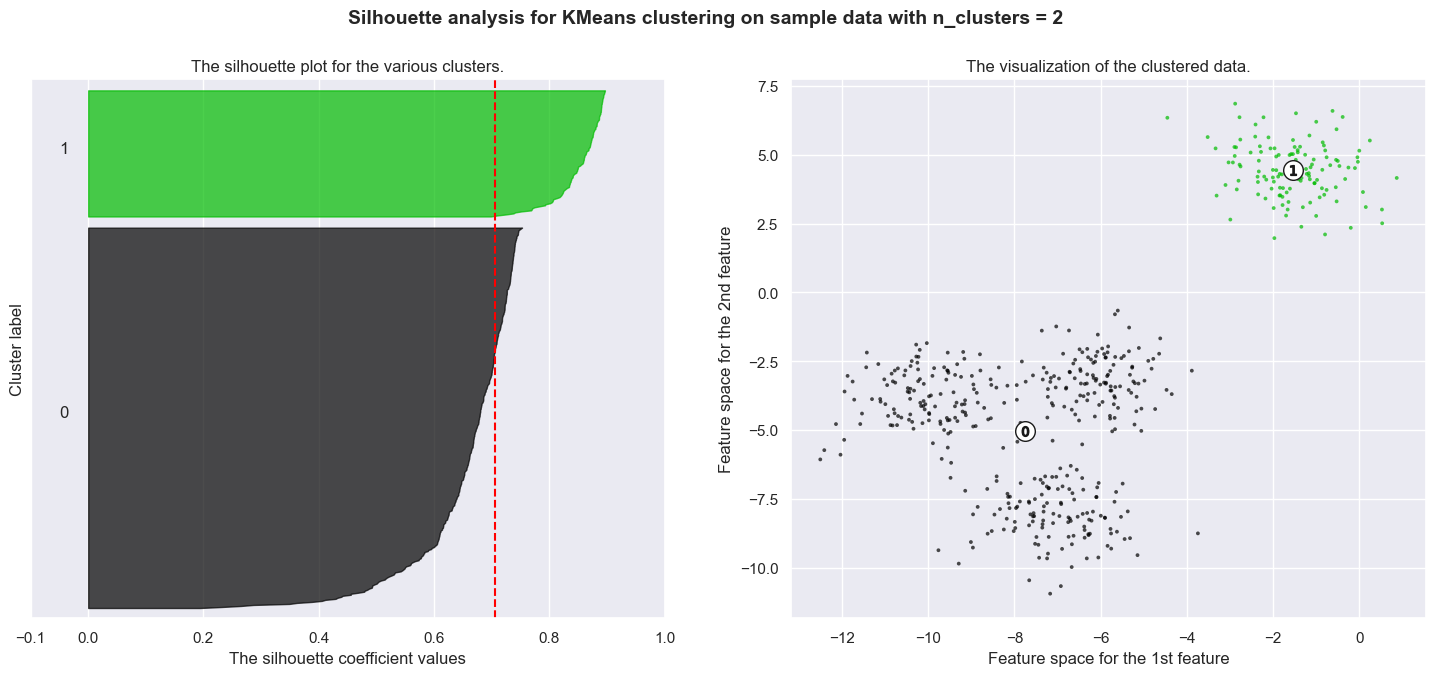

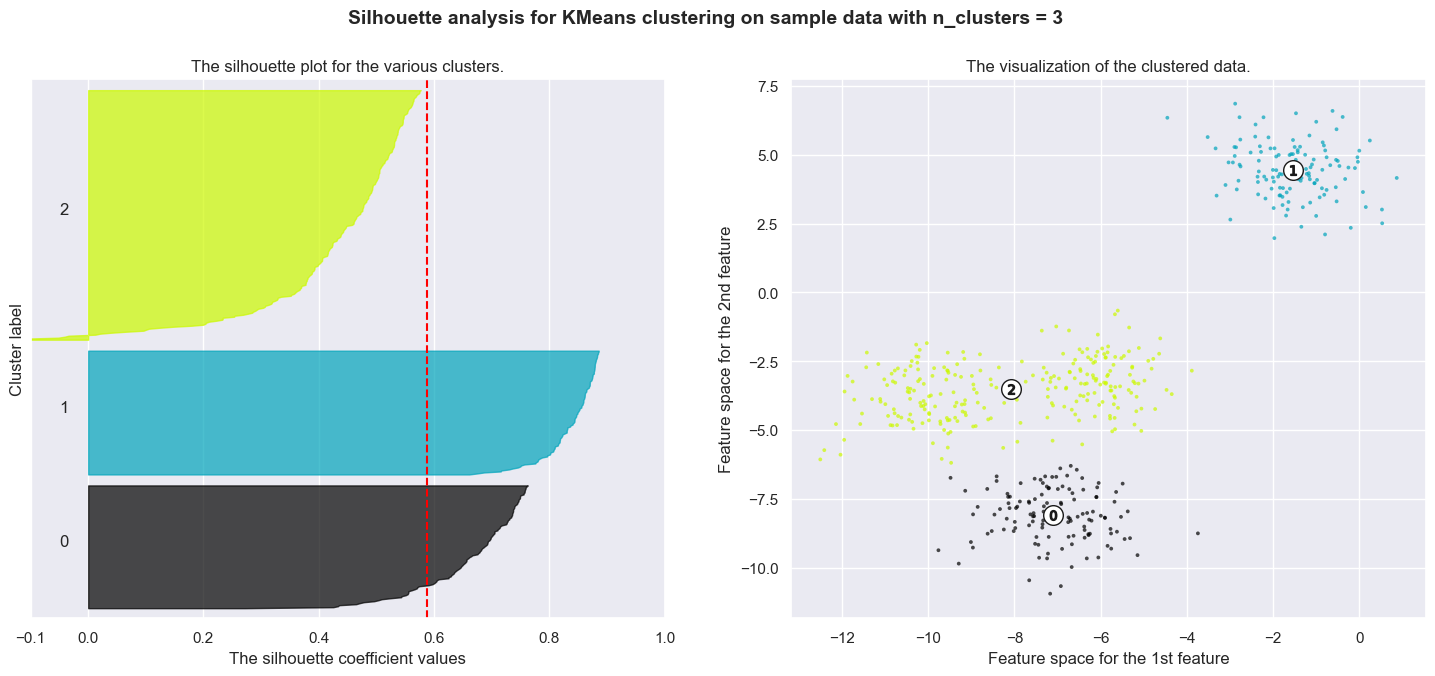

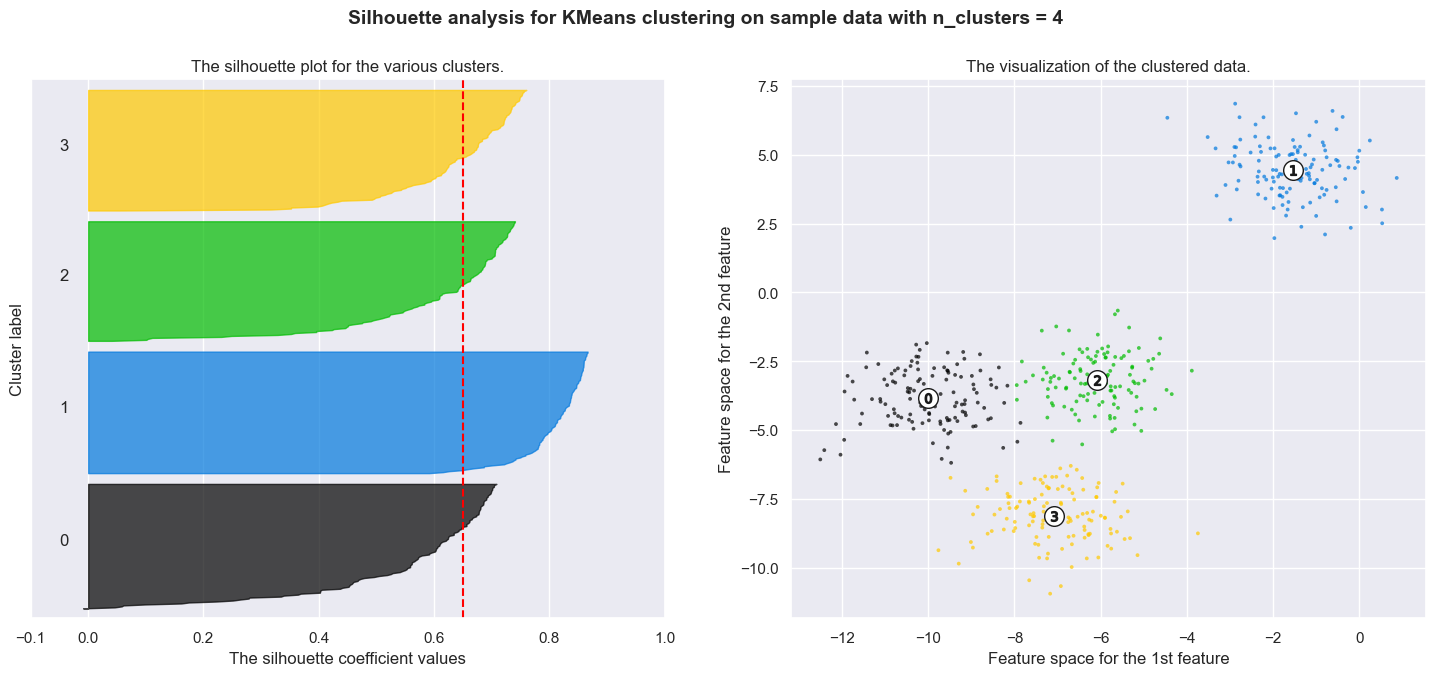

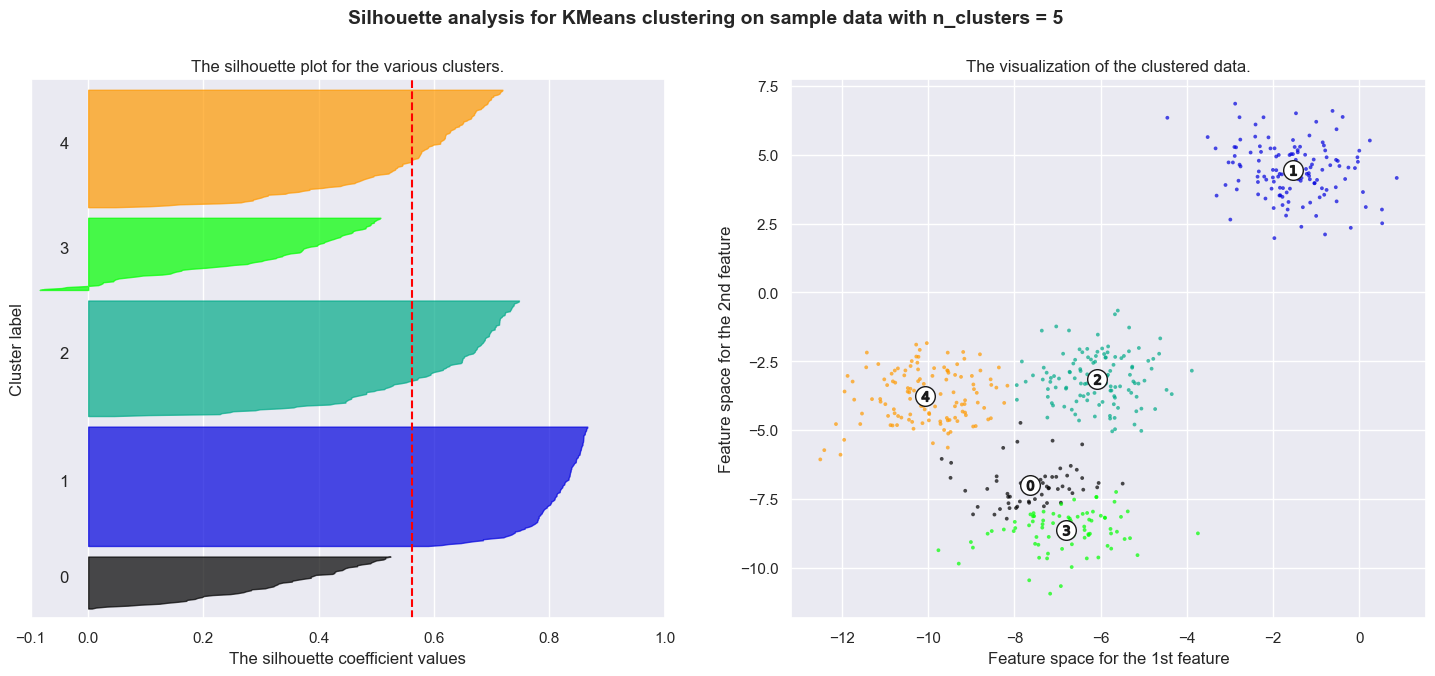

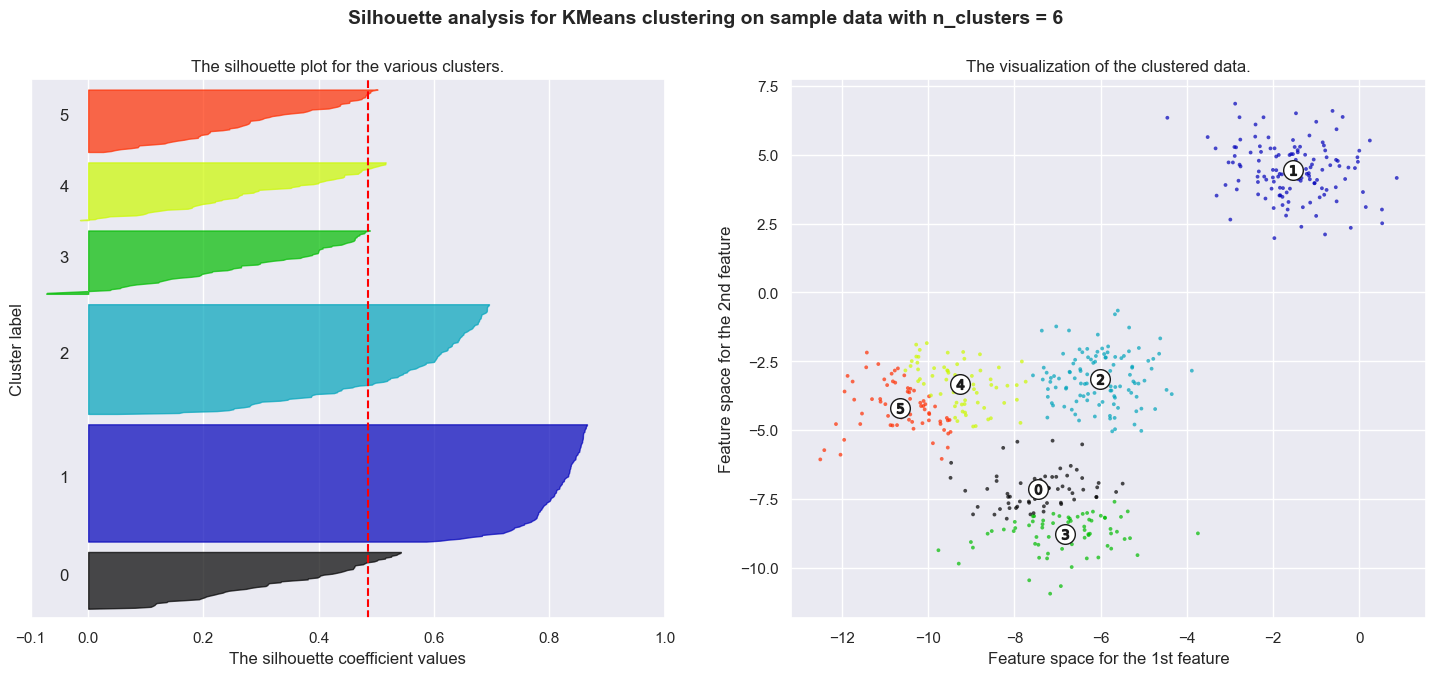

In [56]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

### Weitere Maße

Es gibt viele weitere Bewertungsmetriken für Clustering. Das folgende Codebeispiel zeigt, wie man sie im Zusammenhang mit dem DBSCAN-Algorithmus berechnet.


In [57]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Homogeneity: %0.3f" % metrics.homogeneity_score(y, labels))
print("Completeness: %0.3f" % metrics.completeness_score(y, labels))
print("V-measure: %0.3f" % metrics.v_measure_score(y, labels))
print("Adjusted Rand Index: %0.3f" % metrics.adjusted_rand_score(y, labels))
print("Adjusted Mutual Information: %0.3f"
      % metrics.adjusted_mutual_info_score(y, labels, average_method='arithmetic'))
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(X, labels))




Homogeneity: 0.068
Completeness: 0.325
V-measure: 0.112
Adjusted Rand Index: 0.007
Adjusted Mutual Information: 0.105
Silhouette Coefficient: -0.403
